<a href="https://colab.research.google.com/github/juliene-pearl/FUNDAI-Laboratories-Ysolana/blob/main/Lab2_Search_Algorithms_Ysolana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Maze Solving Using BFS, DFS, and A* Search

## Fundamentals of Artificial Intelligence

**Name:** Ysolana, Juliene Pearl D.
**Course:** BSCSAI
**Section:** 2A
**Date:** August 20, 2026

**GitHub URL:** https://github.com/juliene-pearl/FUNDAI-Laboratories-Ysolana

## Description
This laboratory implements BFS, DFS, and A* Search to solve a maze.
The search results are visualized using matplotlib.


In [137]:
from collections import deque
import heapq
import numpy as np
import matplotlib.pyplot as plt

## Maze Class

The 'Maze' class stores the grid, start position, and goal position.
The value '0' represents an open cell.
The value '1' represents a wall.

In [138]:
from IPython.core.events import post_execute
class Maze:
  def __init__(self, grid, start, goal):
    self.grid = grid
    self.start = start
    self.goal = goal
    self.rows = len(grid)
    self.cols = len(grid[0]) if self.rows > 0 else 0

  def inside(self, pos):
      r, c = pos
      return 0 <= r < self.rows and 0 <= c < self.cols

  def passable (self, pos):
      if not self.inside(pos):
          return False
      r, c = pos
      return self.grid[r][c] == 0

  def neighbors(self, pos):
      r, c = pos
      directions = [(-1, 0), (1,0), (0, -1), (0,1)]
      result = []

      for dr, dc in directions:
          nr, nc = r + dr, c + dc
          next_pos = (nr, nc)

          if self.passable(next_pos):
              result.append(next_pos)

      return result

## SearchResult Class

The 'SearchResult' class stores the output of each search algorithm.
It includes the algorithm name, success status, path, visited order, and parent map.

In [139]:
class SearchResult:
    def __init__(self, algorithm, success, path, visited_order, parent, root):
        self.algorithm = algorithm
        self.success = success
        self.path = path
        self.visited_order = visited_order
        self.parent = parent
        self.root = root

        self.path_set = set(path)
        self.visited_set = set(visited_order)

    @property
    def path_length(self):
        return len(self.path)

    @property
    def nodes_expanded (self):
        return len(self.visited_order)

    def summary(self):
        print(f"Algorithm: {self.algorithm}")
        print(f"Success: {self.success}")
        print(f"Path length: {self.path_length}")
        print(f"Nodes expanded/popped: {self.nodes_expanded}")
        print(f"Path: {self.path}")
        print("-" * 50)


## SearchSolver Class

The 'SearchSolver, class contains the implementation of BFS, DFS, and A* Search.

In [140]:
from logging import currentframe
class SearchSolver:
    def __init__(self, maze):
        self.maze = maze
    def _reconstruct_path(self, parent, goal):
        path = []
        current = goal

        while current is not None:
            path.append(current)
            current = parent[current]

        path.reverse()
        return path

    def _heuristic(self, a, b):
          return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def bfs(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("BFS", False, [], [], {start: None}, start)

        frontier = deque([start])
        visited = {start}
        parent = {start: None}
        visited_order = []
        success = False

        while frontier:
            current = frontier.popleft()
            visited_order.append(current)

            if current == goal:
                success = True
                break
            for neighbor in self.maze.neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    parent[neighbor] = current
                    frontier.append(neighbor)

        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
              algorithm="BFS",
              success=success,
              path=path,
              visited_order=visited_order,
              parent=parent,
              root=start
        )
    def dfs(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("DFS", False, [], [], {start: None}, start)

        frontier = [start]
        visited = {start}
        parent = {start: None}
        visited_order = []
        success = False

        while frontier:
            current = frontier.pop()
            visited_order.append(current)

            if current == goal:
                success = True
                break

            # reveresed is used so that the first neighbor appears explored first
            for neighbor in reversed(self.maze.neighbors(current)):
                if neighbor not in visited:
                    visited.add(neighbor)
                    parent[neighbor] = current
                    frontier.append(neighbor)

        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
            algorithm="DFS",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )

    def astar(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("A* Search", False, [], [], {start: None}, start)

        counter = 0
        open_heap = []
        heapq.heappush(open_heap, (0, counter, start))

        g_score = {start: 0}
        parent = {start: None}
        visited = set()
        visited_order = []
        success = False

        while open_heap:
            f, _, current = heapq.heappop(open_heap)

            if current in visited:
                continue

            visited.add(current)
            visited_order.append(current)

            if current == goal:
                success = True
                break

            for neighbor in self.maze.neighbors(current):
                tentative_g = g_score[current] + 1

                if tentative_g < g_score.get(neighbor, float('inf')):
                    g_score[neighbor] = tentative_g
                    f_score = tentative_g + self._heuristic(neighbor, goal)

                    parent[neighbor] = current
                    counter += 1
                    heapq.heappush(open_heap, (f_score, counter, neighbor))

        path = self._reconstruct_path(parent, goal) if success else[]
        return SearchResult(
            algorithm="A* Search",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )




## Sample Maze

The maze uses:

-'0' for open cells
-'1' for walls

In [141]:
grid = [
      [0, 0, 0, 0, 1, 0, 0],
      [1, 1, 0, 1, 1, 0, 1],
      [0, 0, 0, 0, 0, 0, 0],
      [0, 1, 1, 1, 1, 1, 0],
      [0, 0, 0, 0, 0, 0, 0],
      [0, 1, 1, 1, 1, 1, 0],
      [0, 0, 0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (6, 6)

maze = Maze(grid, start, goal)
solver = SearchSolver(maze)

In [142]:
bfs_result = solver.bfs()
dfs_result = solver.dfs()
astar_result = solver.astar()

In [143]:
bfs_result.summary()
dfs_result.summary()
astar_result.summary()

Algorithm: BFS
Success: True
Path length: 13
Nodes expanded/popped: 30
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
--------------------------------------------------
Algorithm: DFS
Success: True
Path length: 17
Nodes expanded/popped: 17
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------
Algorithm: A* Search
Success: True
Path length: 13
Nodes expanded/popped: 14
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
--------------------------------------------------


## Visualization using matplotlib

The visualization shows:

- Black : wall
- White: open cell
- Light blue: visited/ expanded cells
- Yellow: final path
- Green: start
- Red: goal

In [144]:
def visualize_search(maze, result, title="Search Result"):
    img = np.ones((maze.rows, maze.cols, 3))

    # Draw walls
    for r in range(maze.rows):
        for c in range(maze.cols):
            if maze.grid[r][c] == 1:
                img[r, c] = (0.1, 0.1, 0.1)

    if result is not None:
        # Draw visited/ expanded cells
        for r, c in result.visited_set:
            if maze.grid[r][c] == 0:
                img[r, c] = (0.75, 0.87, 1.0)

        # Draw final path
        for r, c in result.path_set:
          if maze.grid[r][c] == 0:
              img[r, c] = (1.0, 0.85, 0.3)

    # Draw start and goal
    img[maze.start] = (0.2, 0.8, 0.2)
    img[maze.goal] = (0.9, 0.2, 0.2)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

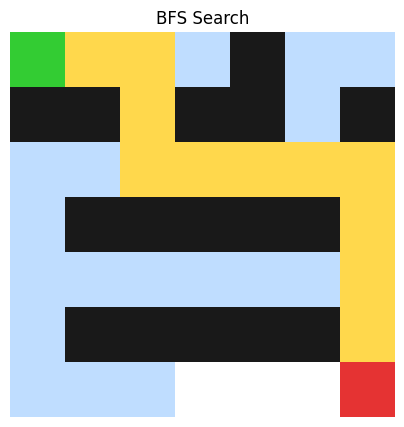

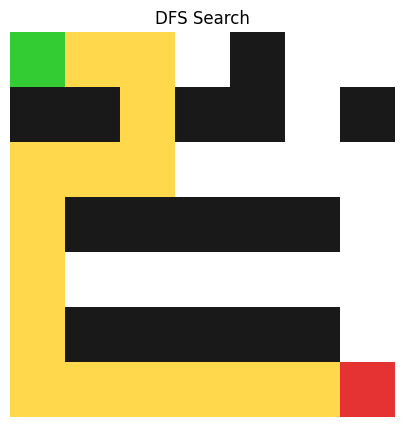

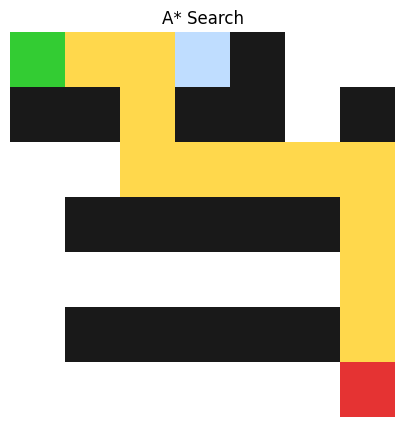

In [145]:
visualize_search(maze, bfs_result, "BFS Search")
visualize_search(maze, dfs_result, "DFS Search")
visualize_search(maze, astar_result, "A* Search")

 ## Search Tree Documentation

 The search tree is generated from the parent map.
 Each child node is connected to its predecessor.
 ## STEP 15>>>>